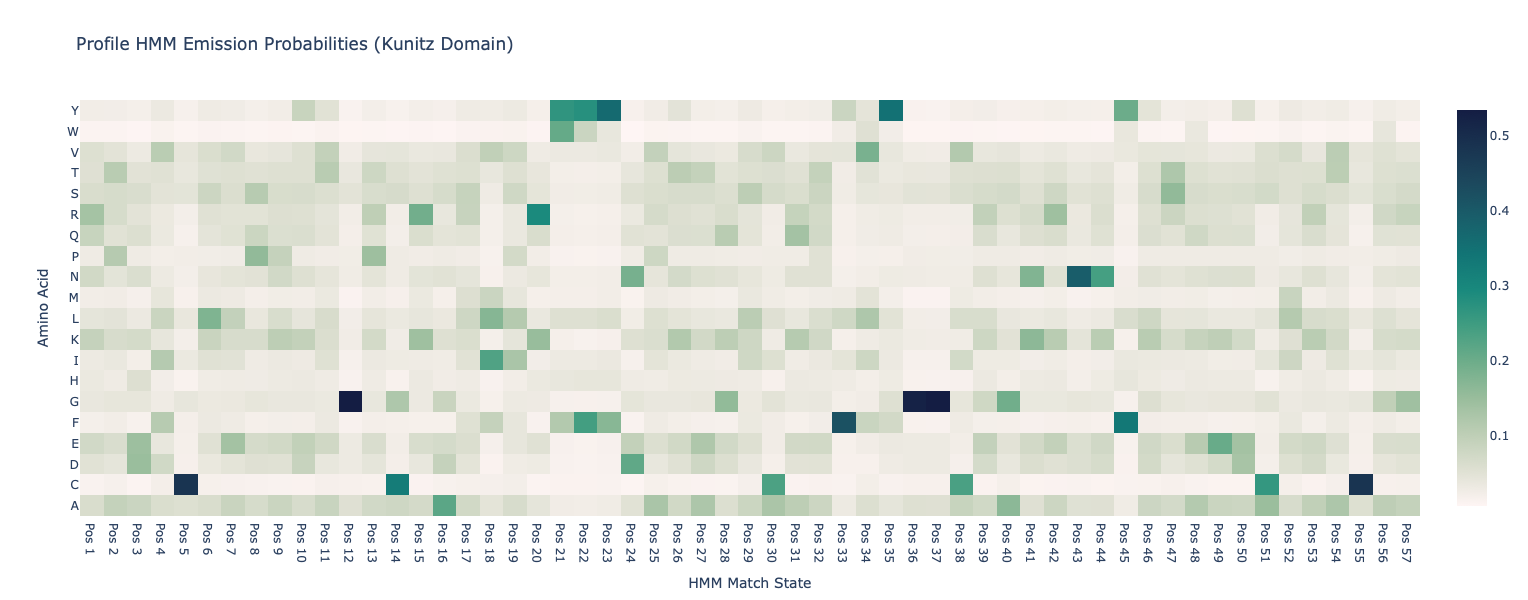

In [8]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

def generate_hmm_heatmap(hmm_file):
    amino_acids = []
    emission_data = []
    
    with open(hmm_file, 'r') as f:
        lines = f.readlines()
        
    parsing_started = False
    for line in lines:
        parts = line.split()
        if not parts: continue
        
        # Identify the amino acid order from the header
        if line.startswith("HMM ") and not amino_acids:
            amino_acids = parts[1:]
            continue
            
        # Match states start with an integer index
        if parts[0].isdigit():
            # Match emissions are the first 20 numbers after the index
            
            raw_scores = [float(x) if x != '*' else float('inf') for x in parts[1:21]]
            
            # 2. Convert negative log-probabilities to raw probabilities: P = 2^(-score)
            probs = [2**(-s) if s != float('inf') else 0.0 for s in raw_scores]
            
            # 3. Normalize probabilities so they sum to 1.0 at each position
            total = sum(probs)
            if total > 0:
                probs = [p / total for p in probs]
            
            emission_data.append(probs)

    
    df_hmm = pd.DataFrame(emission_data, columns=amino_acids).T
    df_hmm.columns = [f"Pos {i+1}" for i in range(df_hmm.shape[1])]

    # 4. Generate the Plotly Heatmap
    fig = go.Figure(data=go.Heatmap(
        z=df_hmm.values,
        x=df_hmm.columns,
        y=df_hmm.index,
        colorscale='tempo',
        hovertemplate="Position: %{x}<br>Residue: %{y}<br>Prob: %{z:.4f}<extra></extra>"
    ))

    fig.update_layout(
        title="Profile HMM Emission Probabilities (Kunitz Domain)",
        xaxis_title="HMM Match State",
        yaxis_title="Amino Acid",
        template="plotly_white",
        height=600
    )
    
    return fig, df_hmm



fig, df_hmm = generate_hmm_heatmap('kunitz_clean.hmm')

fig.show()